In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [9]:
!git clone https://github.com/huydeptrai12/Neural-Network

Cloning into 'Neural-Network'...
remote: Enumerating objects: 248, done.
remote: Counting objects: 100% (248/248), done.
remote: Compressing objects: 100% (154/154), done.
remote: Total 248 (delta 131), reused 192 (delta 83), pack-reused 0 (from 0)
Receiving objects: 100% (248/248), 196.10 KiB | 8.53 MiB/s, done.
Resolving deltas: 100% (131/131), done.


In [10]:
%cd /kaggle/working/Neural-Network
!ls

/kaggle/working/Neural-Network
Neural-Network	environ.yml  nn_test   requirements.txt
README.md	nn	     nn_train  settings.py


In [7]:
!pip install numpy


[notice] A new release of pip is available: 23.0.1 -> 24.2
[notice] To update, run: pip install --upgrade pip


In [12]:
!pip3 install -r Neural-Network/requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 17.1 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.7/48.7 MB 18.4 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 31.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.7/247.7 kB 19.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 407.8/407.8 kB 26.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.7/124.7 kB 11.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 11.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.9/83.9 kB 8.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.4/214.4 kB 19.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 

In [21]:
import sys
import os
path = os.getcwd()
sys.path.append(path)

import random

# Related third party imports
import matplotlib.pyplot as plt
import numpy as np

# Local application/library specific imports
import nn.initialize
from nn.commons.maths import relu, softmax
from nn.commons.library import (
    configure_directory,
    read_model,
)
from nn.network.models import nn
from nn.embedding.models import Embedding
from nn.convolution.models import Convolution
from nn.pooling.models import Pooling
from nn.flatten.models import Flatten
from nn.dropout.models import Dropout
from nn.dense.models import Dense
from nn_train.image.settings import se_hPars

from nn_train.image.prepare_dataset import load_cifar10_data

########################## CONFIGURE ##########################
random.seed(1)
np.random.seed(1)

np.set_printoptions(threshold=10)

np.seterr(all='warn')

configure_directory()

X_train, y_train, X_test, y_test = load_cifar10_data(limit=20000)

In [22]:
embedding = Embedding(X_data=X_train,
                      Y_data=y_train,
                      X_scale=True,
                      Y_encode=True,
                      batch_size=64,
                      relative_size=(1, 0, 0))

name = 'NUMBER-Convolution-16-2_Pooling-3-Max_Flatten_Dense-64-relu_Dense-10-softmax'

se_hPars['learning_rate'] = 0.001
se_hPars['softmax_temperature'] = 5

layers = [
    embedding,
    Convolution(unit_filters=16, filter_size=(3, 3), strides=(1, 1), activate=relu),
    Pooling(pool_size=(2, 2)),
    Convolution(unit_filters=32, filter_size=(3, 3), strides=(1, 1), activate=relu),
    Convolution(unit_filters=32, filter_size=(3, 3), strides=(1, 1), activate=relu),
    Pooling(pool_size=(2, 2)),
    Flatten(),
    Dense(128, relu),
    Dropout(0.2),
    Dense(10, softmax)
]


In [23]:
model = nn(layers=layers, name=name)

model.initialize(loss='CCE', se_hPars=se_hPars.copy(), end='\r')

In [24]:
model.train(epochs=10, init_logs=False, report=False)

KeyboardInterrupt: 

In [17]:
X_test_small = X_test[:number]
y_test_small = y_test[:number]

In [18]:
predicted = model.predict(X_test_small, X_scale=True).P
x = (predicted == y_test_small)
print(x.sum() / number)

0.56


In [20]:
number = 2000
test_batch_size = 50
num_of_batch = number / test_batch_size
x = 0
for i in range(int(num_of_batch)):
    X_test_small = X_test[i * test_batch_size : (i + 1) * test_batch_size]
    y_test_small = y_test[i * test_batch_size : (i + 1) * test_batch_size]
    predicted = model.predict(X_test_small, X_scale=True).P
    x += (predicted == y_test_small).sum()
print(x)

1018


In [13]:
model.write()

Make: /kaggle/working/Neural-Network/models/1729230008_NUMBER-Convolution-16-2_Pooling-3-Max_Flatten_Dense-64-relu_Dense-10-softmax.pickle


In [16]:
!ls

1729230008_NUMBER-Convolution-16-2_Pooling-3-Max_Flatten_Dense-64-relu_Dense-10-softmax.pickle


In [15]:
%cd models

/kaggle/working/Neural-Network/models


In [22]:
%cd ..

/kaggle/working/Neural-Network


In [19]:
import matplotlib.pyplot as plt
import math

In [20]:
def foo(y_validation_re, predictions, x_validation_normalized):
    numbers_to_display = 25
    num_cells = math.ceil(math.sqrt(numbers_to_display))
    plt.figure(figsize=(20, 20))
    for plot_index in range(numbers_to_display): 
        predicted_label = predictions[plot_index]
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        color_map = 1 if predicted_label == y_validation_re[plot_index] else 0
        plt.subplot(num_cells, num_cells, plot_index + 1)
        plt.imshow(x_validation_normalized[plot_index])
        plt.xlabel(predicted_label)
        plt.ylabel(color_map)
    plt.subplots_adjust(hspace=1, wspace=0.5)   
    plt.show()

/tmp/ipykernel_30/362033289.py:11: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(num_cells, num_cells, plot_index + 1)


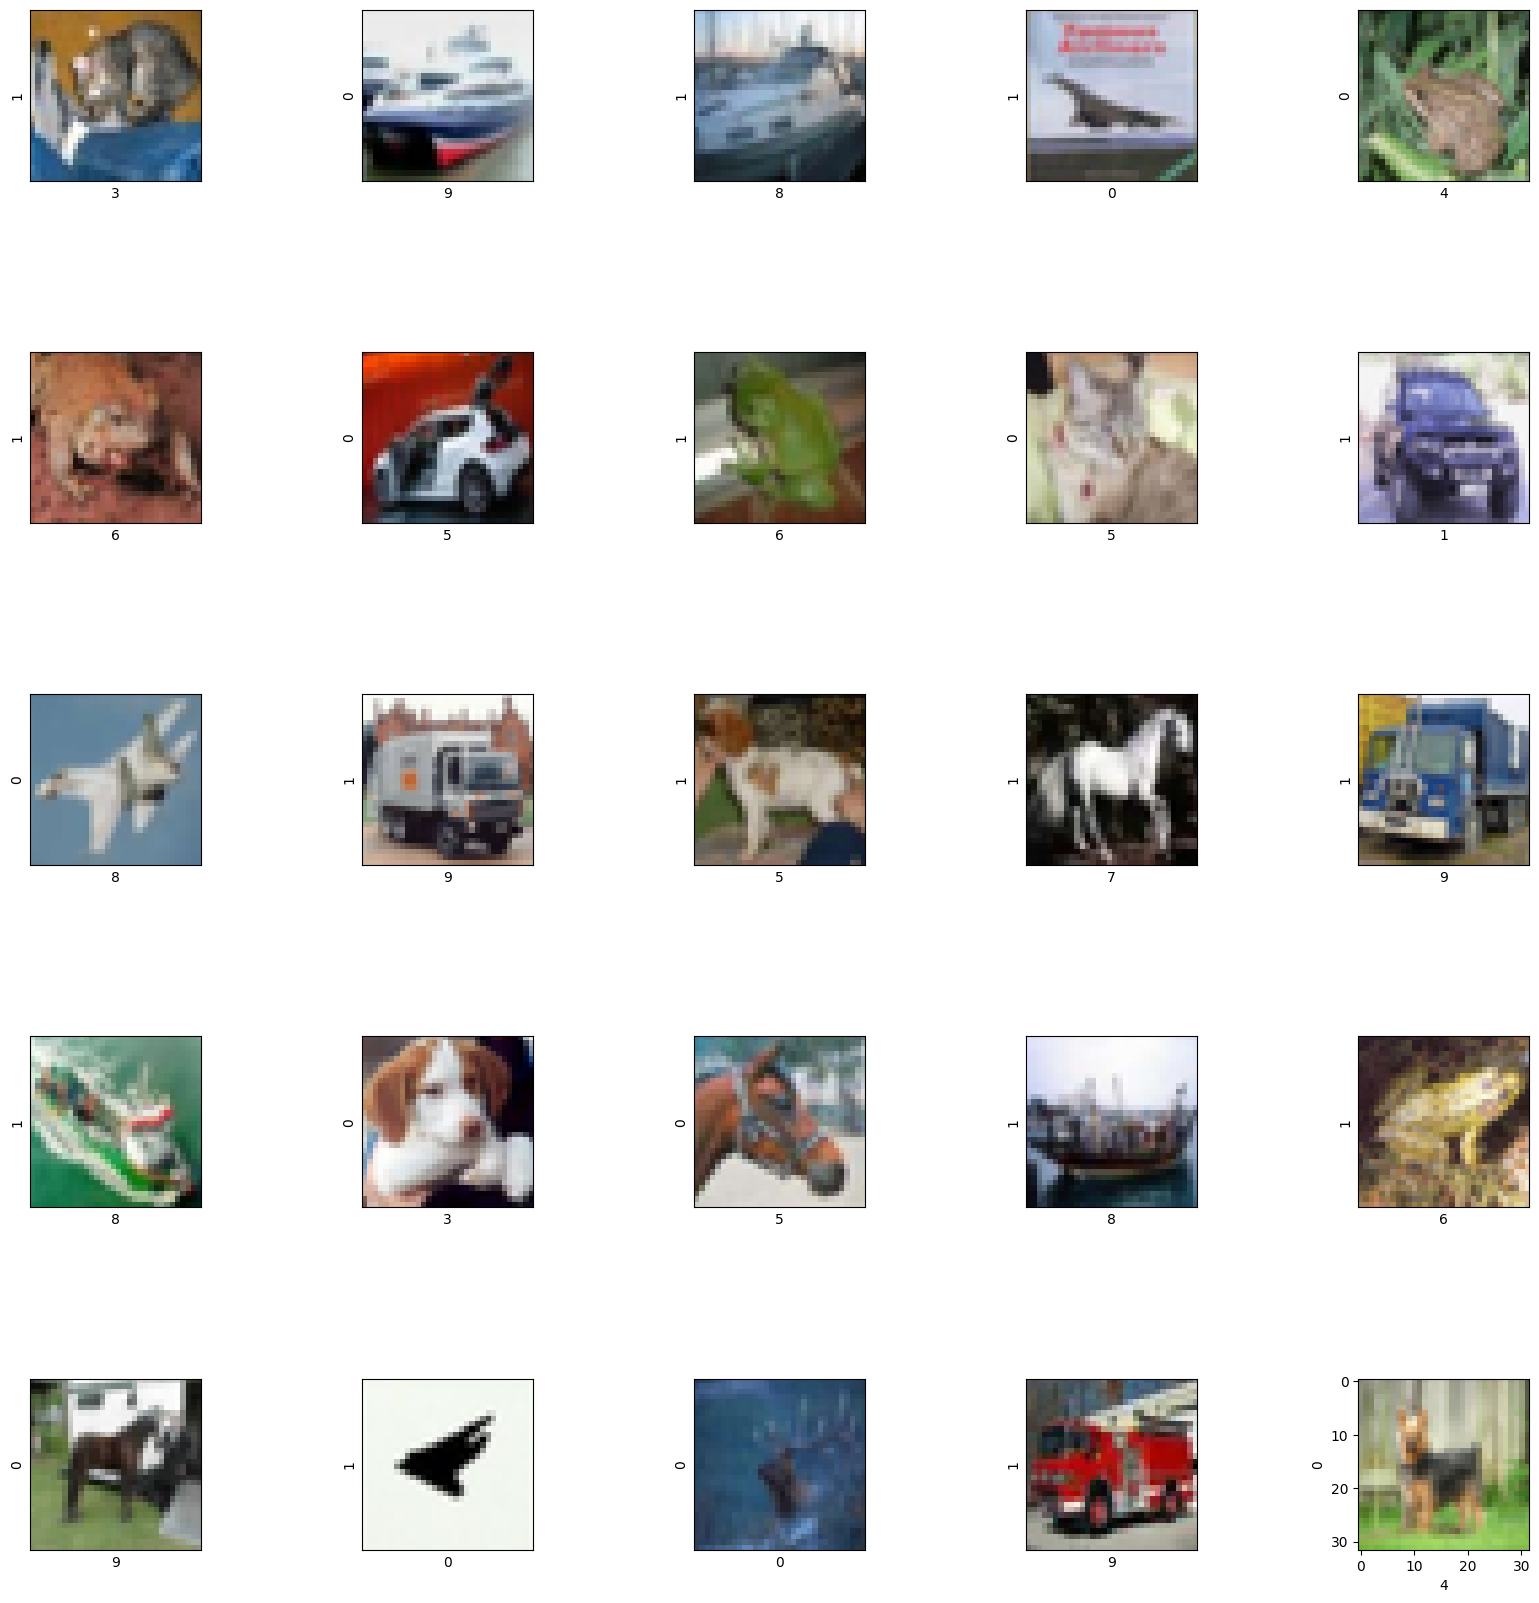

In [21]:
foo(y_test_small, predicted, X_test_small)